<a href="https://colab.research.google.com/github/abd500253-coder/Machine_Learning_Journey/blob/main/Function_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price']]
df.sample(6)

,carat,depth,table,price
40135,0.41,62.2,57.0,1115
21846,1.26,61.9,55.0,9907
39451,0.50,63.7,55.0,1077
8661,1.16,59.6,59.0,4455
14491,1.00,58.7,67.0,5853
11323,1.05,60.3,55.0,4987


# Model without Function Transformer

In [ ]:
from scipy.stats import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
# import KNN
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

model_2 = KNeighborsRegressor()
model_2.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
y1_pred = model_1.predict(X_test)
y2_pred = model_2.predict(X_test)
# checking metrics for LinearRegression and KNN
print('-----LinearRegression-----')
print('MSE: ', mean_squared_error(y_test, y1_pred))
print('MAE: ', mean_absolute_error(y_test, y1_pred))
print('R2: ', r2_score(y_test, y1_pred))
print('-----KNeighborsRegressor-----')
print('MSE: ', mean_squared_error(y_test, y2_pred))
print('MAE: ', mean_absolute_error(y_test, y2_pred))
print('R2: ', r2_score(y_test, y2_pred))

-----LinearRegression-----
MSE:  2333883.1792799835
MAE:  994.736665092202
R2:  0.853185544894256
-----KNeighborsRegressor-----
MSE:  2186568.9187059696
MAE:  841.0271598071931
R2:  0.8624524452633446


Text(0.5, 1.0, 'Carat QQ Plot')

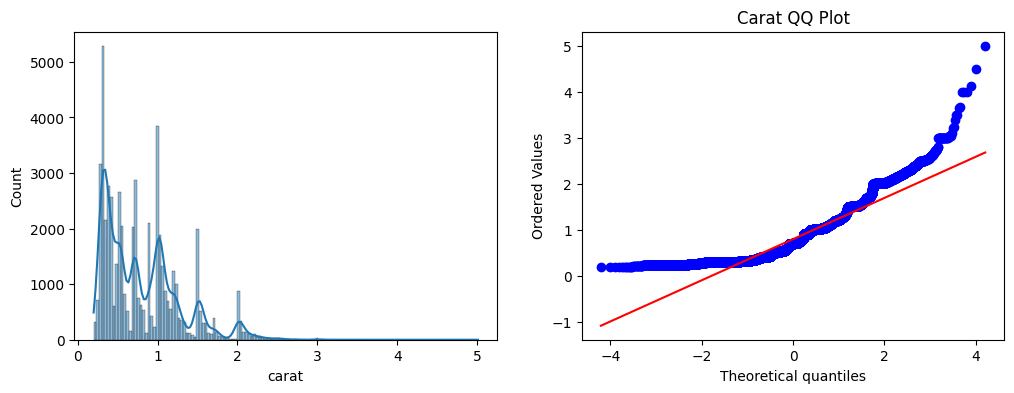

In [ ]:
from scipy.stats import probplot
# Making carat pdf vs QQ plot for carat
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['carat'], kde=True, ax=ax[0])
plt.title('Carat Distribution')

probplot(df['carat'], dist='norm', plot=ax[1])
plt.title('Carat QQ Plot')

# Model with Function Trasformer

In [ ]:
trf = FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [ ]:
model_1 = LinearRegression()
model_1.fit(X_train_transformed, y_train)

model_2 = KNeighborsRegressor()
model_2.fit(X_train_transformed, y_train)

KNeighborsRegressor()

In [ ]:
y3_pred = model_1.predict(X_test_transformed)
y4_pred = model_2.predict(X_test_transformed)
# checking metrics for LinearRegression and KNN
print('-----LinearRegression-----')
print('MSE: ', mean_squared_error(y_test, y3_pred))
print('MAE: ', mean_absolute_error(y_test, y3_pred))
print('R2: ', r2_score(y_test, y3_pred))
print('-----KNeighborsRegressor-----')
print('MSE: ', mean_squared_error(y_test, y4_pred))
print('MAE: ', mean_absolute_error(y_test, y4_pred))
print('R2: ', r2_score(y_test, y4_pred))

-----LinearRegression-----
MSE:  2911475.467355443
MAE:  1237.6973476564945
R2:  0.8168517224476503
-----KNeighborsRegressor-----
MSE:  2119729.9722914346
MAE:  821.752966258806
R2:  0.8666569931108163
